# Project 01: Energy-Delay Optimization of a Three-Stage CMOS Buffer

In [24]:
# --- 0. IMPORTS AND PATH SETUP ---
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
from PyLTSpice import SimRunner, SpiceEditor
from PyLTSpice.log.ltsteps import LTSpiceLogReader
import os
from pathlib import Path

# Configure seaborn style
sns.set_style("whitegrid")

# --- 0.1 FILE AND PATH SETUP ---
PROJECT_SIM_FOLDER = Path("../res/srcs/project-01")
OUTPUT_FOLDER = Path("./output/project-01")
OUTPUT_FIG_FOLDER = OUTPUT_FOLDER / "figs"

# Create the output folder if it doesn't exist
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

# Create the output fig folder if it doesn't exist
if not os.path.exists(OUTPUT_FIG_FOLDER):
    os.makedirs(OUTPUT_FIG_FOLDER)

## Step 01: Minimum inverter sizing

In [11]:
# --- 1. RUN PMOS SIZING SIMULATION ---
# Simulate minimum inverter with varying PMOS width
# Range: 100nm to 300nm, step 10nm

LT_SPICE_PATH = "D:/Softwares/ADI/LTspiceXVII/XVIIx64.exe"

# Initialize simulation runner
runner = SimRunner(output_folder=str(OUTPUT_FOLDER), simulator=LT_SPICE_PATH)

# Load the simulation netlist
netlist = SpiceEditor(PROJECT_SIM_FOLDER / "01-PMOS_sizing" / "inverter_min_PMOS-sizing.asc")

# Run the simulation
print("Running PMOS sizing simulation...")
_, log = runner.run_now(netlist)
print(f"Simulation complete. Log file: {log}")

Running PMOS sizing simulation...
Simulation complete. Log file: output\project-01\inverter_min_PMOS-sizing_1.log


In [18]:
# --- 2. EXTRACT MEASUREMENTS INTO DATAFRAME ---
# Parse the .measure outputs from LTspice log file

data = LTSpiceLogReader(log.as_posix()) # pyright: ignore[reportOptionalMemberAccess]

# Extract step parameter values (wp in meters)
# WP values: from 100n to 300n with step 10n
wp_values = np.arange(100e-9, 310e-9, 10e-9)

# Build DataFrame with measurements
df_pmos = pd.DataFrame({
    "wp_nm": wp_values[:data.step_count] * 1e9,  # Convert to nm
    "wp_m": wp_values[:data.step_count],
    "delay_rise_ps": np.array(data["delay_rise"]) * 1e12,  # Convert to ps
    "delay_rise_s": data["delay_rise"],
    "delay_fall_ps": np.array(data["delay_fall"]) * 1e12,  # Convert to ps
    "delay_fall_s": data["delay_fall"]
})

# Add columns for delay difference
df_pmos["delay_diff_s"] = df_pmos["delay_rise_s"] - df_pmos["delay_fall_s"]
df_pmos["delay_diff_ps"] = df_pmos["delay_diff_s"] * 1e12  # Convert to ps

# Display summary
print(f"Loaded {len(df_pmos)} simulation points")
print(f"\nWP range: {df_pmos['wp_nm'].min():.0f}nm - {df_pmos['wp_nm'].max():.0f}nm")
df_pmos.filter(items=["wp_nm", "delay_rise_ps", "delay_fall_ps", "delay_diff_ps"])

Loaded 21 simulation points

WP range: 100nm - 300nm


,wp_nm,delay_rise_ps,delay_fall_ps,delay_diff_ps
0,100.0,9.97138,5.72204,4.24934
1,110.0,9.70113,5.92541,3.77572
2,120.0,9.33749,6.18797,3.14952
3,130.0,9.10699,6.42506,2.68193
4,140.0,8.91590,6.64458,2.27132
5,150.0,8.66756,6.85354,1.81402
6,160.0,8.45371,7.05084,1.40287
7,170.0,8.35536,7.29262,1.06274
8,180.0,8.11481,7.57756,0.53725
9,190.0,8.09288,7.83968,0.25320


In [21]:
# --- 3. INTERPOLATION TO FIND EQUAL DELAY POINT ---
# Find where delay_rise = delay_fall using linear interpolation
# Resolution: 5nm

# Create interpolation functions for rise and fall delays
interp_rise = interp1d(df_pmos["wp_nm"], df_pmos["delay_rise_s"], kind="linear")
interp_fall = interp1d(df_pmos["wp_nm"], df_pmos["delay_fall_s"], kind="linear")

# Generate fine-grained WP values at 5nm resolution using linspace
wp_fine = np.linspace(df_pmos["wp_nm"].min(), df_pmos["wp_nm"].max(), int((df_pmos["wp_nm"].max() - df_pmos["wp_nm"].min()) / 5) + 1)

# Compute interpolated delays
delay_rise_interp = interp_rise(wp_fine)
delay_fall_interp = interp_fall(wp_fine)

# Compute delay difference at fine resolution
delay_diff_interp = delay_rise_interp - delay_fall_interp

# Find crossover point (where delay_diff crosses zero)
crossover_indices = np.where(np.diff(np.sign(delay_diff_interp)))[0]

if len(crossover_indices) > 0:
    # Linear interpolation between the two nearest points
    idx = crossover_indices[0]
    wp1, wp2 = wp_fine[idx], wp_fine[idx + 1]
    diff1, diff2 = delay_diff_interp[idx], delay_diff_interp[idx + 1]

    # Linear interpolation to find exact wp where diff = 0
    wp_crossover = wp1 - diff1 * (wp2 - wp1) / (diff2 - diff1)

    # Compute delay at crossover point
    delay_crossover = interp_rise(wp_crossover)

    print("=== CROSSOVER POINT FOUND ===")
    print(f"Optimal WP width: {wp_crossover:.1f} nm")
    print(f"Delay at crossover: {delay_crossover * 1e12:.2f} ps")
else:
    print("No crossover point found in the range.")
    wp_crossover = None
print()


# --- 3.1. DISPLAY TABLE WITH HIGHLIGHTED CROSSOVER ---
# Create a formatted table showing all measurements and highlight crossover

# Prepare display DataFrame (convert to more readable units)
df_display = df_pmos[["wp_nm", "delay_rise_s", "delay_fall_s", "delay_diff_ps"]].copy()
df_display.columns = ["WP (nm)", "Delay Rise (ps)", "Delay Fall (ps)", "Diff (ps)"]
df_display["Delay Rise (ps)"] = df_display["Delay Rise (ps)"] * 1e12
df_display["Delay Fall (ps)"] = df_display["Delay Fall (ps)"] * 1e12
df_display = df_display.round(2)

# Print table with manual highlighting
print("=== PMOS SIZING MEASUREMENTS ===")
print(f"(WP values near crossover point {wp_crossover:.1f}nm highlighted)\n")

# Header
print(f"{'WP (nm)':>10} | {'Rise (ps)':>12} | {'Fall (ps)':>12} | {'Diff (ps)':>10}")
print("-" * 55)

# Data rows
for idx, row in df_display.iterrows():
    wp = row["WP (nm)"]
    rise = row["Delay Rise (ps)"]
    fall = row["Delay Fall (ps)"]
    diff = row["Diff (ps)"]

    # Highlight rows near the crossover point (±10nm)
    if wp_crossover is not None and abs(wp - wp_crossover) <= 10:
        marker = " <<< "
    else:
        marker = ""

    print(f"{wp:>10.0f} | {rise:>12.2f} | {fall:>12.2f} | {diff:>10.2f}{marker}")

=== CROSSOVER POINT FOUND ===
Optimal WP width: 195.7 nm
Delay at crossover: 7.98 ps

=== PMOS SIZING MEASUREMENTS ===
(WP values near crossover point 195.7nm highlighted)

   WP (nm) |    Rise (ps) |    Fall (ps) |  Diff (ps)
-------------------------------------------------------
       100 |         9.97 |         5.72 |       4.25
       110 |         9.70 |         5.93 |       3.78
       120 |         9.34 |         6.19 |       3.15
       130 |         9.11 |         6.43 |       2.68
       140 |         8.92 |         6.64 |       2.27
       150 |         8.67 |         6.85 |       1.81
       160 |         8.45 |         7.05 |       1.40
       170 |         8.36 |         7.29 |       1.06
       180 |         8.11 |         7.58 |       0.54
       190 |         8.09 |         7.84 |       0.25 <<< 
       200 |         7.90 |         8.08 |      -0.19 <<< 
       210 |         7.77 |         8.31 |      -0.55
       220 |         7.70 |         8.53 |      -0.83
     

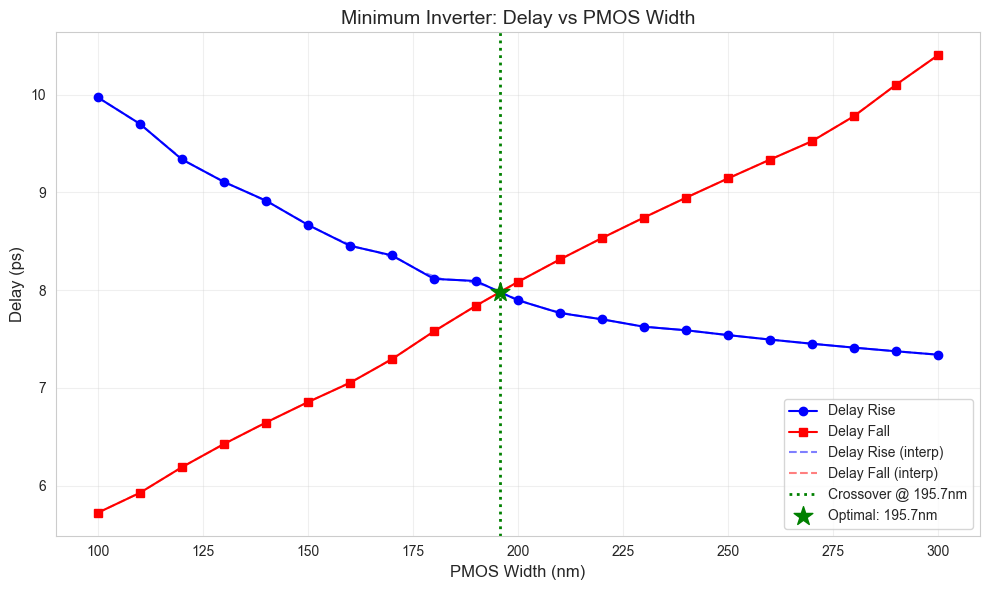


Plot saved to: output\project-01\figs\pmos_sizing_delays.png


In [25]:
# --- 4. PLOT DELAY VS WP ---
# Visualize the delay characteristics

fig, ax = plt.subplots(figsize=(10, 6))

# Plot measured points
ax.plot(df_pmos["wp_nm"], df_pmos["delay_rise_s"] * 1e12, "o-",
        label="Delay Rise", color="blue", markersize=6)
ax.plot(df_pmos["wp_nm"], df_pmos["delay_fall_s"] * 1e12, "s-",
        label="Delay Fall", color="red", markersize=6)

# Plot interpolated lines
ax.plot(wp_fine, delay_rise_interp * 1e12, "--",
        label="Delay Rise (interp)", color="blue", alpha=0.5)
ax.plot(wp_fine, delay_fall_interp * 1e12, "--",
        label="Delay Fall (interp)", color="red", alpha=0.5)

# Mark crossover point
if wp_crossover is not None:
    ax.axvline(x=wp_crossover, color="green", linestyle=":", linewidth=2,
               label=f"Crossover @ {wp_crossover:.1f}nm")
    ax.scatter([wp_crossover], [delay_crossover * 1e12],
               color="green", s=200, zorder=5, marker="*",
               label=f"Optimal: {wp_crossover:.1f}nm")

ax.set_xlabel("PMOS Width (nm)", fontsize=12)
ax.set_ylabel("Delay (ps)", fontsize=12)
ax.set_title("Minimum Inverter: Delay vs PMOS Width", fontsize=14)
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FIG_FOLDER / "pmos_sizing_delays.png", dpi=300)
plt.show()

print(f"\nPlot saved to: {OUTPUT_FIG_FOLDER / "pmos_sizing_delays.png"}")